In [29]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
print(spambase.metadata) 
  
# variable information 
print(spambase.variables) 


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

# Problem 3: AdaBoost Ensemble (25 points)

1. Use an existing package to train an AdaBoost ensemble with 10, 50, 100, and 500 base classifiers on the *SPAMBASE* dataset. Use a
decision tree classifier as the base classification model. Report accuracy, F1 score, and AUC on both the training and testing sets.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [31]:
T_values = [10, 50, 100, 500]

for t in T_values:
    ada = AdaBoostClassifier(n_estimators=t, algorithm='SAMME', random_state=42)
    ada.fit(X_train, y_train.values.ravel())
    
    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)
    
    y_train_prob = ada.predict_proba(X_train)[:, 1]
    y_test_prob = ada.predict_proba(X_test)[:, 1]
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    print(f"\nAdaBoost (T={t})")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("Train F1:", f1_score(y_train, y_train_pred))
    print("Test F1:", f1_score(y_test, y_test_pred))
    print("Train AUC:", roc_auc_score(y_train, y_train_prob))
    print("Test AUC:", roc_auc_score(y_test, y_test_prob))



AdaBoost (T=10)
Train Accuracy: 0.9057971014492754
Test Accuracy: 0.891398783666377
Train F1: 0.8807339449541285
Test F1: 0.8615725359911407
Train AUC: 0.9637749857566099
Test AUC: 0.9544887150089433

AdaBoost (T=50)
Train Accuracy: 0.9347826086956522
Test Accuracy: 0.9209383145091226
Train F1: 0.9155722326454033
Test F1: 0.8976377952755905
Train AUC: 0.9814030064726046
Test AUC: 0.976167527288126

AdaBoost (T=100)
Train Accuracy: 0.9414492753623188
Test Accuracy: 0.9313640312771503
Train F1: 0.9247391952309985
Test F1: 0.911731843575419
Train AUC: 0.9842641771437841
Test AUC: 0.978939002269007

AdaBoost (T=500)
Train Accuracy: 0.9521739130434783
Test Accuracy: 0.9374456993918332
Train F1: 0.9387300408466395
Test F1: 0.9194630872483222
Train AUC: 0.9902119141954956
Test AUC: 0.982838660337886


2. Compare AdaBoost with the Random Forest ensemble for 10, 50, 100, and 500 base learners by looking at various metrics on the training
and testing sets.

On the training set, both AdaBoost and Random Forest achieve very high accuracy and F1 scores as the number of base learners increases, though Random Forest reaches near-perfect metrics even with 100 trees, while AdaBoost gradually improves from ~0.91 to ~0.95 accuracy. 

On the test set, Random Forest consistently outperforms AdaBoost for smaller numbers of learners (T = 10, 50), with higher accuracy, F1, and AUC, indicating better generalization and robustness to overfitting. 

As T increases, AdaBoost steadily improves, reaching test accuracy of 0.937 and AUC of 0.983 at T = 500, but Random Forest slightly outperforms it at similar or smaller numbers of trees. 

Overall, Random Forest provides more stable and reliable performance, whereas AdaBoost requires more learners to achieve comparable test metrics.

3. Plot the ROC curves for the decision tree model, Random Forest with 100 trees, and AdaBoost with 100 trees.

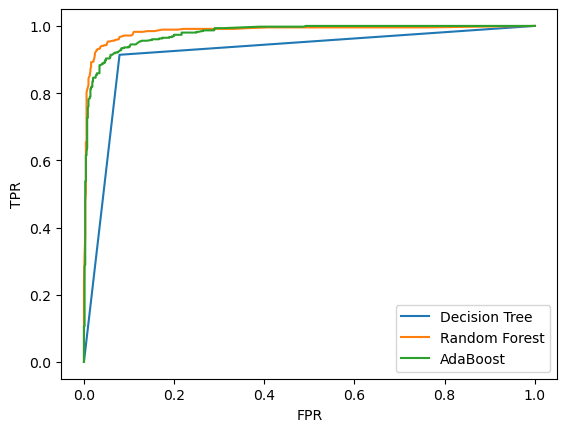

In [32]:
def plot_roc(model, name):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

tree = DecisionTreeClassifier().fit(X_train, y_train.values.ravel())
rf = RandomForestClassifier(n_estimators=100).fit(X_train, y_train.values.ravel())
ada = AdaBoostClassifier(n_estimators=100, algorithm='SAMME').fit(X_train, y_train.values.ravel())

plot_roc(tree, "Decision Tree")
plot_roc(rf, "Random Forest")
plot_roc(ada, "AdaBoost")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()